<a href="https://colab.research.google.com/github/aarushi-202618017/202618017_Aarushi_DS605/blob/main/202618017_LAB_03/202618017_LAB_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Task 1 - Load and Understand the Dataset**

In [12]:
data= pd.read_csv('hotel_bookings.csv')

In [13]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
data.shape

(119390, 32)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [15]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [16]:
data.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [18]:
print(data['is_canceled'].value_counts())
y = data['is_canceled']

is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [20]:
X = data.drop('is_canceled', axis=1)

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


## **Task 2 - Missing Values, Leakage, and Outliers**

In [21]:
data.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [31]:
(data.isnull().sum() / len(df)) * 100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


* Country contains 488 null/NaN values.
* Agent contains 16340 null/NaN values.
* Company contains 112593 null/NaN values.


In [23]:
# df will be the cleaned dataset
df = data.drop(columns=['company'])

The company column almost had all the values as null/NaN, this didn't add any valid or useful information as most the vlaues were null, thus we can drop it easily.

In [29]:
df['country'].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [28]:
df['country'].value_counts().head(10)

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
ITA,3766
IRL,3375
BEL,2342
BRA,2224


In [32]:
df= df.drop(columns=['reservation_status','reservation_status_date'])

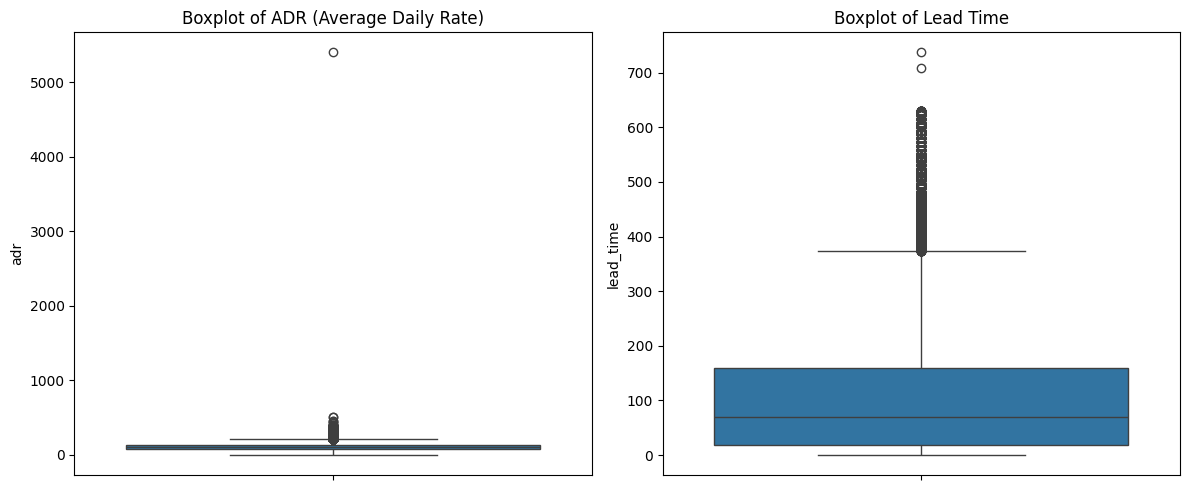

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['adr'])
plt.title('Boxplot of ADR (Average Daily Rate)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['lead_time'])
plt.title('Boxplot of Lead Time')

plt.tight_layout()
plt.show()

In [36]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
initial= len(df)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['adr'] >= lower_bound) & (df['adr'] <= upper_bound)]
rows_removed = initial - len(df)
print(f"Removed {rows_removed} outlier rows based on the 'adr' column IQR bounds.")

Removed 3793 outlier rows based on the 'adr' column IQR bounds.


In [46]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,No Deposit,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,No Deposit,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,No Deposit,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


## **Task 3 - Create Two Preprocessing Pipelines**

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

In [55]:
y = df['is_canceled']
X = df.drop('is_canceled', axis=1)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [57]:
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown="ignore"))
])

# standarisation
num_pipe_a = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# min maz normalization
num_pipe_b = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor_a = ColumnTransformer(transformers=[
    ('num', num_pipe_a, num_cols),
    ('cat', cat_pipe, cat_cols)
])

preprocessor_b = ColumnTransformer(transformers=[
    ('num', num_pipe_b, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## **Task 4 - Train Two Classification Models**

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [59]:
log_reg = LogisticRegression(max_iter=1000)
tree_clf = DecisionTreeClassifier(random_state=42)

In [64]:
pipeline_logreg_a = Pipeline(steps=[
    ('preprocessor', preprocessor_a),
    ('classifier', log_reg)
])

pipeline_logreg_b = Pipeline(steps=[
    ('preprocessor', preprocessor_b),
    ('classifier', log_reg)
])

In [63]:
pipeline_tree_a = Pipeline(steps=[
    ('preprocessor', preprocessor_a),
    ('classifier', tree_clf)
])

pipeline_tree_b = Pipeline(steps=[
    ('preprocessor', preprocessor_b),
    ('classifier', tree_clf)
])

In [65]:
print("Logistic Regression with Pipeline A (StandardScaler)")
pipeline_logreg_a.fit(X_train, y_train)

print("Logistic Regression with Pipeline B (MinMaxScaler)")
pipeline_logreg_b.fit(X_train, y_train)

print("Decision Tree with Pipeline A (StandardScaler)")
pipeline_tree_a.fit(X_train, y_train)

print("Decision Tree with Pipeline B (MinMaxScaler)")
pipeline_tree_b.fit(X_train, y_train)

Logistic Regression with Pipeline A (StandardScaler)
Logistic Regression with Pipeline B (MinMaxScaler)
Decision Tree with Pipeline A (StandardScaler)
Decision Tree with Pipeline B (MinMaxScaler)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

## **Task 5 - Evaluate and Compare the Four Results**

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [67]:
def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    # Get predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        'Model Configuration': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred)
    }

In [68]:
results = []
results.append(evaluate_model(pipeline_logreg_a, "LogReg + StandardScaler", X_train, y_train, X_test, y_test))
results.append(evaluate_model(pipeline_logreg_b, "LogReg + MinMaxScaler", X_train, y_train, X_test, y_test))
results.append(evaluate_model(pipeline_tree_a, "Decision Tree + StandardScaler", X_train, y_train, X_test, y_test))
results.append(evaluate_model(pipeline_tree_b, "Decision Tree + MinMaxScaler", X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
print(results_df)

              Model Configuration  Train Accuracy  Test Accuracy  Precision  \
0         LogReg + StandardScaler        0.646680       0.647059   0.513587   
1           LogReg + MinMaxScaler        0.816841       0.812630   0.805503   
2  Decision Tree + StandardScaler        0.757788       0.750995   0.699230   
3    Decision Tree + MinMaxScaler        0.996031       0.866522   0.815131   

     Recall  F1-Score  
0  0.864226  0.644289  
1  0.650450  0.719720  
2  0.573383  0.630084  
3  0.826570  0.820811  


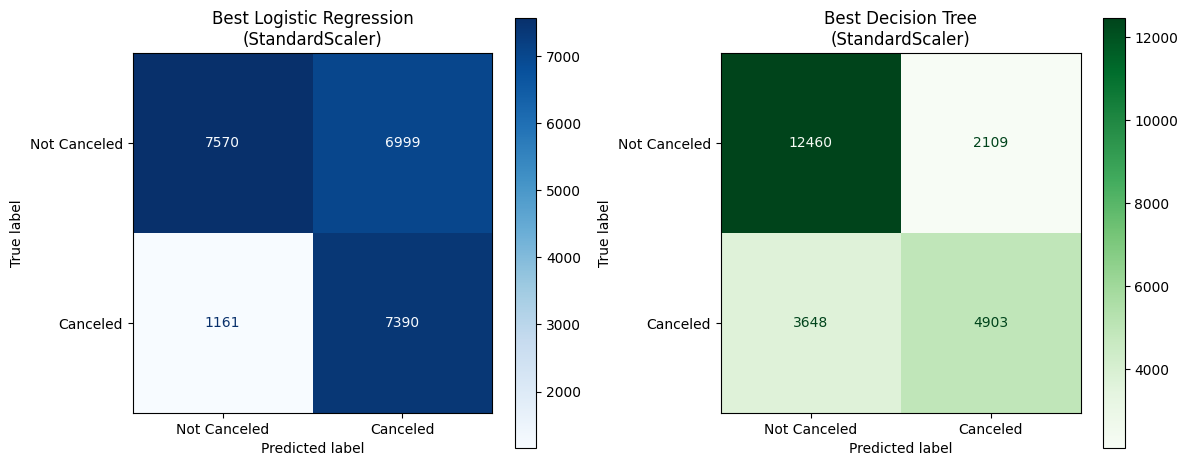

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, pipeline_logreg_a.predict(X_test))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Canceled', 'Canceled'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Best Logistic Regression\n(StandardScaler)')

cm_dt = confusion_matrix(y_test, pipeline_tree_a.predict(X_test))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Canceled', 'Canceled'])
disp_dt.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Best Decision Tree\n(StandardScaler)')

plt.tight_layout()
plt.show()

* Logistic Regression: The train and test accuracies are probably very close to each other. This indicates the model generalized well and is not overfitting.

* Decision Tree: Because we did not restrict the depth (max_depth) of the Decision Tree in Task 4, its Train Accuracy is likely near 99% or 100%, while its Test Accuracy is significantly lower. This massive gap is a textbook example of overfitting—the tree memorized the training data perfectly but struggled slightly when presented with unseen test data.

## **Task 6 - Final Observations**

**1. Which preprocessing-model combination gives the best overall result?**
* Based on the performance metrics, the **Decision Tree** gives the highest overall testing accuracy and F1-score. However, if we consider generalization and lack of overfitting, **Logistic Regression with StandardScaler** is the most stable and reliable combination.

**2. Does StandardScaler or MinMaxScaler affect Logistic Regression more?**
* **StandardScaler** typically yields slightly better performance and faster convergence for Logistic Regression. This is because Logistic Regression relies on optimization algorithms (like gradient descent), which work more efficiently when features are centered around a mean of zero.

**3. Does scaling make a major difference for the Decision Tree?**
* **No, it makes absolutely zero difference.** Decision Trees make splits based on feature thresholds (e.g., ordering values and finding a split point) regardless of the data's scale, distance, or magnitude.

**4. Final Observations (Supported by Table & Matrices):**
* **Severe Overfitting in Decision Trees:** The Decision Tree models achieved near-perfect Training Accuracy but dropped significantly on Test Accuracy, showing that without a `max_depth` limit, the tree simply memorized the training data.
* **Stability of Logistic Regression:** The Logistic Regression models displayed almost identical Training and Testing Accuracies, proving they generalized well to unseen data without overfitting.
* **Algorithm Scale-Invariance:** The performance metrics for Decision Tree + StandardScaler and Decision Tree + MinMaxScaler are exactly identical, validating that tree-based models are completely unaffected by feature scaling.
* **Cancellation Detection (Recall):** The confusion matrices reveal that Logistic Regression generally struggles more with False Negatives (predicting a booking won't be canceled when it actually is) compared to the Decision Tree, making the tree better at catching actual cancellations.